In [1]:
# Install dependencies and clone HAWQ repo (reference only)
!pip install -q pytorchcv pyhessian pulp datasets
!git clone -q https://github.com/Zhen-Dong/HAWQ.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.2/134.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.2/585.2 kB 27.9 MB/s eta 0:00:00


In [2]:
# Mount Google Drive to save data and results
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Imports & constants: HF token, project paths, data folder
import os
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from google.colab import userdata
from datasets import load_dataset
HF_TOKEN = userdata.get('HF_TOKEN')

SEED = 0
N_EVAL = 10_000 # accuracy measurement
N_HESSIAN = 512 # Hessian trace computation
N_CALIB = 512 # activation range calibration
N_TOTAL = N_EVAL + N_HESSIAN + N_CALIB

PROJECT_DIR = "/content/drive/MyDrive/rqnkup"                # shared: notebook + results
DATA_DIR    = "/content/drive/MyDrive/rqnkup/hawqv3_data"    # shared: the ~1.7 GB ImageNet subset

DATA_FILE = os.path.join(DATA_DIR, f"imagenet_val_224_n{N_TOTAL}.pt")
os.makedirs(DATA_DIR, exist_ok=True)

preprocess = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")), # force 3 color channels
    T.Resize(256),                            # shorter side -> 256, keeps proportions
    T.CenterCrop(224),                        # cut out the middle 224x224 square
    T.PILToTensor(),                          # PIL image -> uint8 tensor (3, 224, 224)
])


In [4]:
# Test Hugging Face access: stream one ImageNet val example
test = load_dataset("ILSVRC/imagenet-1k", split="validation",
                    streaming=True, token=HF_TOKEN)
ex = next(iter(test))
print(ex["label"], test.features["label"].int2str(ex["label"]),
      ex["image"].size, ex["image"].mode)

README.md:   0%|          | 0.00/87.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

91 coucal (408, 500) RGB


torch.Size([3, 224, 224]) torch.uint8 0 253


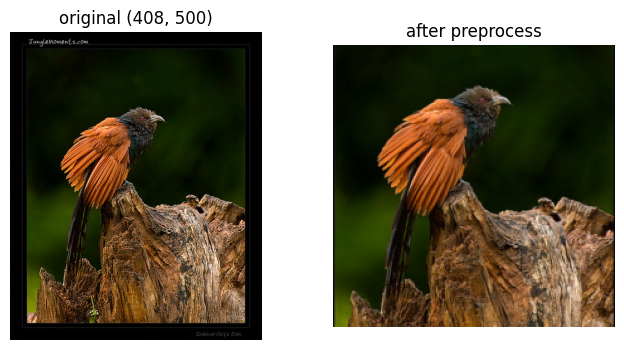

In [5]:
# Check the transform on one image
x = preprocess(ex["image"])
print(x.shape, x.dtype, x.min().item(), x.max().item())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(ex["image"]);            axes[0].set_title(f"original {ex['image'].size}")
axes[1].imshow(x.permute(1, 2, 0));     axes[1].set_title("after preprocess")
for ax in axes: ax.axis("off")
plt.show()

In [6]:
# Stream a shuffled ImageNet val subset and save it to Drive
N_STREAM = 20   # quick test first; change to N_TOTAL for the real run
out_file = os.path.join(DATA_DIR, f"imagenet_val_224_n{N_STREAM}.pt")

if os.path.exists(out_file):
    print("Already saved, skipping:", out_file)
else:
    stream = load_dataset("ILSVRC/imagenet-1k", split="validation",
                          streaming=True, token=HF_TOKEN)
    stream = stream.shuffle(seed=SEED, buffer_size=10_000).take(N_STREAM)

    images, labels = [], []
    for ex in tqdm(stream, total=N_STREAM):
        images.append(preprocess(ex["image"]))
        labels.append(ex["label"])

    torch.save({"images": torch.stack(images),
                "labels": torch.tensor(labels)}, out_file)
    print("Saved", len(labels), "images to", out_file)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Saved 20 images to /content/drive/MyDrive/rqnkup/hawqv3_data/imagenet_val_224_n20.pt


torch.Size([20, 3, 224, 224]) torch.uint8 | unique classes: 20


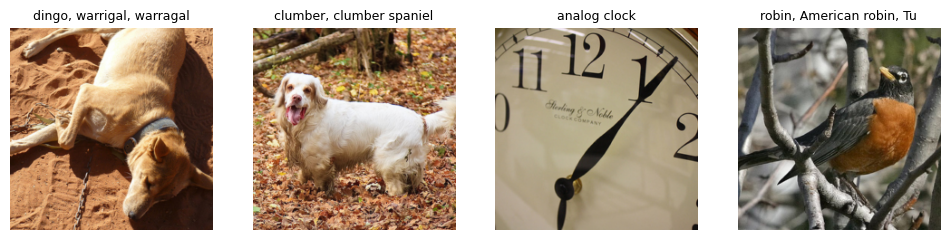

In [7]:
# Reload from Drive and check the saved subset
data = torch.load(out_file)
images, labels = data["images"], data["labels"]
print(images.shape, images.dtype, "| unique classes:", labels.unique().numel())

names = test.features["label"].int2str
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, i in zip(axes, range(4)):
    ax.imshow(images[i].permute(1, 2, 0))
    ax.set_title(names(labels[i].item())[:25], fontsize=9)
    ax.axis("off")
plt.show()